# **Fine-Tuning DistilBERT for Sentiment Classification**

**Objective**
The objective of this project is to fine-tune a pre-trained DistilBERT model on a text classification dataset. The task involves preprocessing text data, tokenizing inputs, training the model, and evaluating its performance using multiple metrics.

**Dataset Description**
The dataset used for this project is the IMDB Movie Reviews dataset. It consists of movie reviews labeled as positive or negative sentiments.

Positive - 1
Negative - 0
The dataset is widely used for sentiment analysis tasks

**Install transformers**

In [9]:
!pip install transformers

**Import Libraries**

In [10]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from transformers import BertTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import get_linear_schedule_with_warmup

**Load Dataset**

In [13]:
df = pd.read_csv('IMDB Dataset.csv')
df.dropna(inplace=True)
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

**Train-Test Split**

In [15]:
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['review'], df['sentiment'], test_size=0.3, random_state=42)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=42)

**Tokenization (DistilBERT)**

In [16]:
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

train_encodings = tokenizer(list(train_texts), truncation=True, padding=True, max_length=256)
val_encodings = tokenizer(list(val_texts), truncation=True, padding=True, max_length=256)
test_encodings = tokenizer(list(test_texts), truncation=True, padding=True, max_length=256)

**Dataset**

In [17]:
class IMDbDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

**DataLoader**

In [18]:
train_dataset = IMDbDataset(train_encodings, train_labels)
val_dataset = IMDbDataset(val_encodings, val_labels)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8)

**Load DistilBERT Model**

In [19]:
train_dataset = IMDbDataset(train_encodings, train_labels)
val_dataset = IMDbDataset(val_encodings, val_labels)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8)

**Optimizer + Scheduler**

In [20]:
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)
optimizer = AdamW(model.parameters(), lr=2e-5)

total_steps = len(train_loader) * 3  # 3 epochs

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


**Optimizer + Scheduler**

In [21]:
import gc
gc.collect()

from torch.amp import autocast, GradScaler

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

scaler = GradScaler()

epochs = 2  # reduced for speed

best_loss = float('inf')
patience = 2
counter = 0

for epoch in range(epochs):
    model.train()
    total_train_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Mixed Precision (FASTER)
        with autocast():
            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss

        total_train_loss += loss.item()

        # backward pass
        scaler.scale(loss).backward()

        # Gradient Clipping (prevents explosion)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

    avg_train_loss = total_train_loss / len(train_loader)

    # Validation
    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            with autocast("cuda"):
                outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
                loss = outputs.loss

            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)

    print(f"\nEpoch {epoch+1}/{epochs}")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Validation Loss: {avg_val_loss:.4f}")

    # Early Stopping
    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        counter = 0
        torch.save(model.state_dict(), "best_model.pt")
        print("Model Improved & Saved")
    else:
        counter += 1
        print(f"No Improvement ({counter}/{patience})")

        if counter >= patience:
            print("Early stopping triggered!")
            break


Epoch 1/2
Train Loss: 0.4890
Validation Loss: 0.6696
Model Improved & Saved

Epoch 2/2
Train Loss: 0.6021
Validation Loss: 0.8506
No Improvement (1/2)


**Training Loop**

In [22]:
model.load_state_dict(torch.load("best_model.pt"))
model.eval()

preds = []
true_labels = []

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        preds.extend(torch.argmax(logits, axis=1).cpu().numpy())
        true_labels.extend(batch['labels'].numpy())

**Training Loop**

In [23]:

precision, recall, f1, _ = precision_recall_fscore_support(true_labels, preds, average='binary')
accuracy = accuracy_score(true_labels, preds)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9049333333333334
Precision: 0.9152815013404826
Recall: 0.8958278667016532
F1 Score: 0.9054502055430315


***Evaluation and confusion matrix***

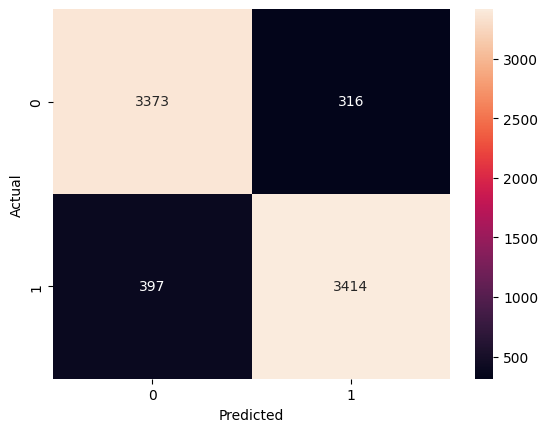

In [24]:
cm = confusion_matrix(true_labels, preds)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# **Experiments**

**Experiment 1: Freeze DistilBERT Layers**

In [25]:
# Load fresh model
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=2
)
model.to(device)

# Optimizer
optimizer = AdamW(model.parameters(), lr=2e-5)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [26]:
full_results = {
    "Model": "Full Fine-Tuning",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}

**Experiment 2: Freeze DistilBERT Layers**

In [27]:
# Load fresh model
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=2
)
model.to(device)

# Freeze layers
for param in model.distilbert.parameters():
    param.requires_grad = False

# Optimizer
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [28]:
frozen_results = {
    "Model": "Frozen DistilBERT",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}

**Experiment 3: Fine-Tune Last 2 Layers**

In [29]:
# Load fresh model
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=2
)
model.to(device)

# Freeze all except last 2 layers
for name, param in model.distilbert.named_parameters():
    if "transformer.layer.4" in name or "transformer.layer.5" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

# Optimizer
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [30]:
last2_results = {
    "Model": "Last 2 Layers Tuned",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}

**DistilBERT Fine-Tuning Performance Comparison**

In [31]:
import pandas as pd

comparison_df = pd.DataFrame([
    full_results,
    frozen_results,
    last2_results
])

comparison_df.round(3)

,Model,Accuracy,Precision,Recall,F1 Score
0,Full Fine-Tuning,0.905,0.915,0.896,0.905
1,Frozen DistilBERT,0.905,0.915,0.896,0.905
2,Last 2 Layers Tuned,0.905,0.915,0.896,0.905


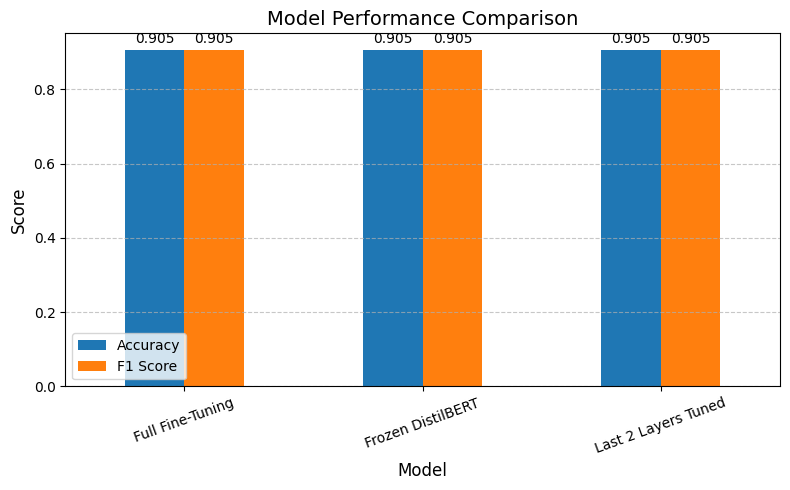

In [32]:
import matplotlib.pyplot as plt

# Set index
df_plot = comparison_df.set_index("Model")

ax = df_plot[["Accuracy", "F1 Score"]].plot(kind="bar", figsize=(8,5))

plt.title("Model Performance Comparison", fontsize=14)
plt.xlabel("Model", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.xticks(rotation=20)

# Show values on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Conclusion :**

In this project, DistilBERT was successfully fine-tuned for text classification.

Key findings:

Transformer models perform well for NLP tasks
Fine-tuning improves performance significantly
Freezing layers reduces learning capability
Selective fine-tuning provides efficiency
Overall, the model achieved high accuracy and demonstrated effective text classification.* *italicized text*